<a href="https://colab.research.google.com/github/SiddharthVESIT/SEM6/blob/main/mldllab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Improved Preprocessing
def preprocess(df):
    # Extract 'Title' (Mr, Mrs, Miss, etc.) from Name
    df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Dr', 'Major', 'Rev', 'Sir'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Fill Missing Data
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # Mapping Categorical to Numerical
    df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df['Title'] = df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

    return df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']]

# 2. Data Preparation
X = preprocess(pd.read_csv('train.csv'))
y = pd.read_csv('train.csv')['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training (Tuned)
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

# 4. Evaluation
print(classification_report(y_val, rf.predict(X_val)))
print(f"ROC AUC Score: {roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1]):.4f}")

<>:10: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1176/325506848.py:10: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)


              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

ROC AUC Score: 0.9037


<>:14: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1176/3595858575.py:14: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)


--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       105
           1       0.82      0.74      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

ROC AUC Score: 0.9037


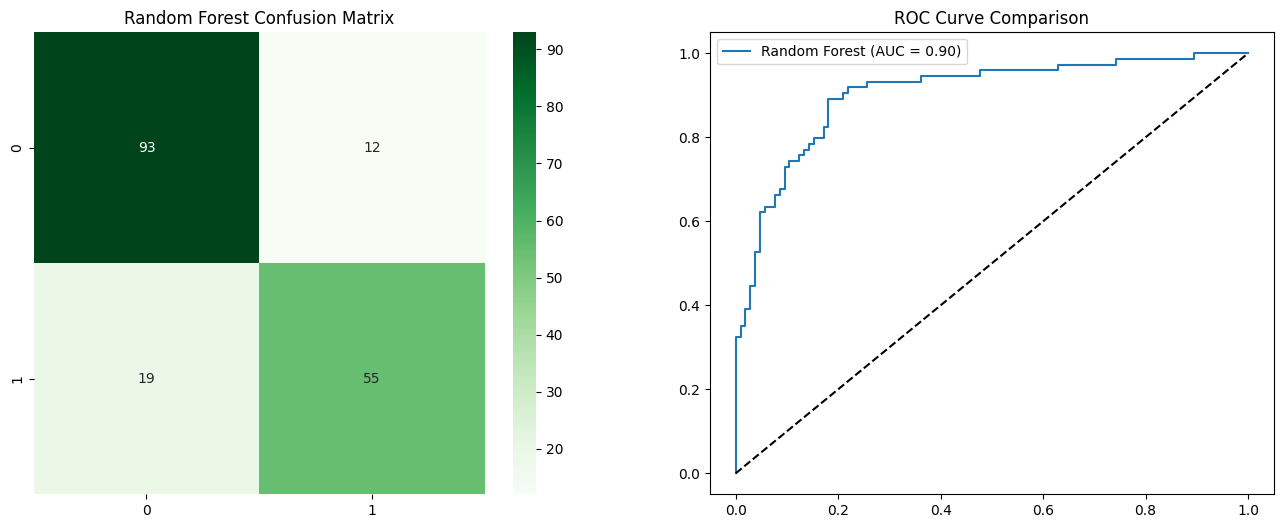

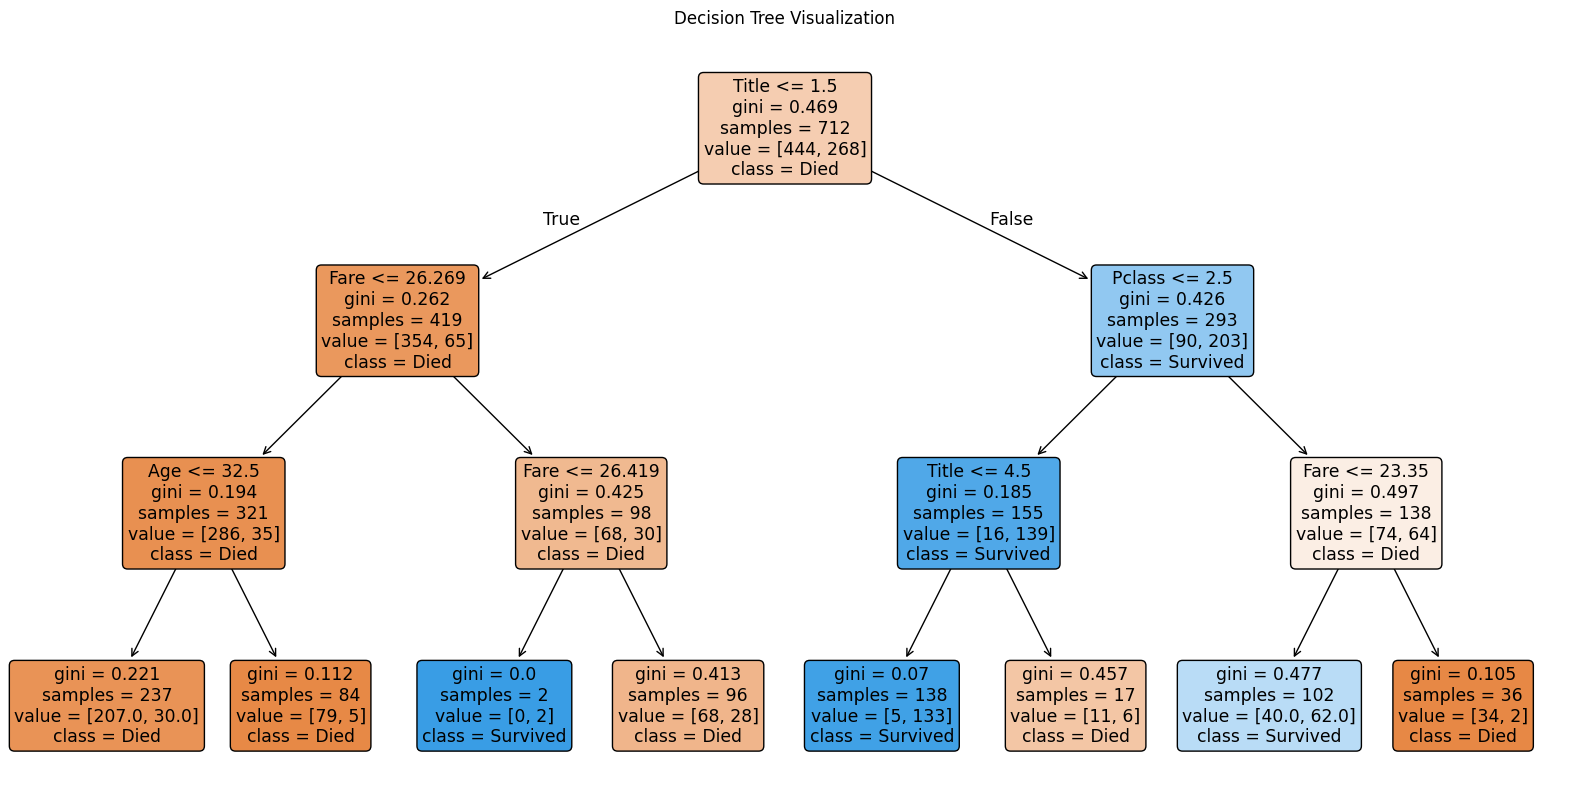

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# 1. Improved Preprocessing (Handles Titles, Missing Data, and Mapping)
def preprocess(df):
    # Extract 'Title' from Name
    df['Title'] = df.Name.str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Dr', 'Major', 'Rev', 'Sir'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Fill Missing Data (Smart Imputation)
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

    # Mapping Categorical to Numerical
    df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df['Title'] = df['Title'].map({"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}).fillna(0)

    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']
    return df[features]

# 2. Data Preparation
raw_data = pd.read_csv('train.csv')
X = preprocess(raw_data.copy())
y = raw_data['Survived']

# Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
# Decision Tree (Simplified for clear visualization)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest (Best performance)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Final Performance Report
rf_preds = rf_model.predict(X_test)
print("--- Random Forest Performance ---")
print(classification_report(y_test, rf_preds))
print(f"ROC AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")

# 5. Visualizations
# A. Plotting Confusion Matrix, ROC, and Feature Importance together
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0])
axes[0].set_title('Random Forest Confusion Matrix')

# ROC Curve
probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
axes[1].plot(fpr, tpr, label=f'Random Forest (AUC = {auc(fpr, tpr):.2f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()
plt.show()

# B. Plot the Tree Logic
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()